In [2]:
import numpy as np
import sys
import copy
import matplotlib.pyplot as plt

In [6]:
A=np.array([1,2,3,4]).reshape(2,2)
B=np.array([5,6,7,8]).reshape(2,2)
A
B

array([[5, 6],
       [7, 8]])

In [7]:
c=np.zeros(4).reshape(2,2)

for i in range(2):
  for j in range(2):
    for k in range(2):
      c[i,j]=c[i,j]+A[i,k]*B[k,j]
c

array([[19., 22.],
       [43., 50.]])

In [8]:
A@B

array([[19, 22],
       [43, 50]])

In [9]:
k=np.array([1,2,3,4]).reshape(2,2)
l=np.array([5,6,7,8]).reshape(2,2)

In [10]:
k@l

array([[19, 22],
       [43, 50]])

In [11]:
import numpy as np

A = np.array([[1, 2, 3],
              [4, 5, 6]])      # A is 2×3

B = np.array([[7, 8],
              [9, 10],
              [11, 12]])       # B is 3×2

          # Result will be 2×2


In [13]:
A@B

array([[ 58,  64],
       [139, 154]])

In [16]:
a=np.array([[1,1,1,9],[2,-3,4,13],[3,4,5,40]],dtype=float)
a

array([[ 1.,  1.,  1.,  9.],
       [ 2., -3.,  4., 13.],
       [ 3.,  4.,  5., 40.]])

In [19]:
n=3
for i in range(n):
  if a[i][i]==0.0:
    sys.exit('divide by zero detected!')
  for j in range(i+1,n):
    ratio=a[j][i]/a[i][i]
    for k in range(n+1):
      a[j][k]=ratio*a[i][k]-a[j][k]
a

array([[ 1. ,  1. ,  1. ,  9. ],
       [ 0. ,  5. , -2. ,  5. ],
       [ 0. ,  0. ,  2.4, 12. ]])

In [21]:
x=np.zeros(n)

In [26]:
x[n-1] = a[n-1][n] / a[n-1][n-1]
for i in range(n-2,-1,-1):
  x[i] = a[i, n]
  for j in range(i+1, n):
     x[i] = x[i]- a[i,j] * x[j]
  x[i] = x[i] / a[i,i]
x

array([1., 3., 5.])

In [28]:
import numpy as np

In [30]:
A=np.array([[2,-1,0],[-1,2,-1],[0,-1,2]],dtype=float)
A

array([[ 2., -1.,  0.],
       [-1.,  2., -1.],
       [ 0., -1.,  2.]])

In [33]:
np.linalg.eigvals(A)

array([3.41421356, 2.        , 0.58578644])

In [35]:
lam, vec = np.linalg.eig(A)
lam

array([3.41421356, 2.        , 0.58578644])

In [37]:
vec

array([[-5.00000000e-01, -7.07106781e-01,  5.00000000e-01],
       [ 7.07106781e-01,  4.05405432e-16,  7.07106781e-01],
       [-5.00000000e-01,  7.07106781e-01,  5.00000000e-01]])

In [39]:
Lam=np.diag(lam);Lam

array([[3.41421356, 0.        , 0.        ],
       [0.        , 2.        , 0.        ],
       [0.        , 0.        , 0.58578644]])

In [40]:
vec_inv= np.linalg.inv(vec)

In [41]:
vec_inv

array([[-5.00000000e-01,  7.07106781e-01, -5.00000000e-01],
       [-7.07106781e-01,  3.14018492e-16,  7.07106781e-01],
       [ 5.00000000e-01,  7.07106781e-01,  5.00000000e-01]])

In [44]:
A=vec@Lam@vec_inv;A

array([[ 2.00000000e+00, -1.00000000e+00, -1.05947398e-15],
       [-1.00000000e+00,  2.00000000e+00, -1.00000000e+00],
       [-7.77156117e-16, -1.00000000e+00,  2.00000000e+00]])

In [47]:
A4 = vec @ Lam**4 @ vec_inv;A4

array([[ 42., -48.,  26.],
       [-48.,  68., -48.],
       [ 26., -48.,  42.]])

In [48]:
A@A@A@A

array([[ 42., -48.,  26.],
       [-48.,  68., -48.],
       [ 26., -48.,  42.]])

In [55]:
 A = np.array([[0.6, 0.9], [0.1, 0.6]]);A # Markov matrix
 lam, vec = np.linalg.eig(A)
 xinv = np.linalg.inv(vec)
 Lam = np.diag(lam)

In [57]:
norm = []
for power in range(1, 100):
  norm.append(np.linalg.norm(vec @ Lam**power @ xinv))

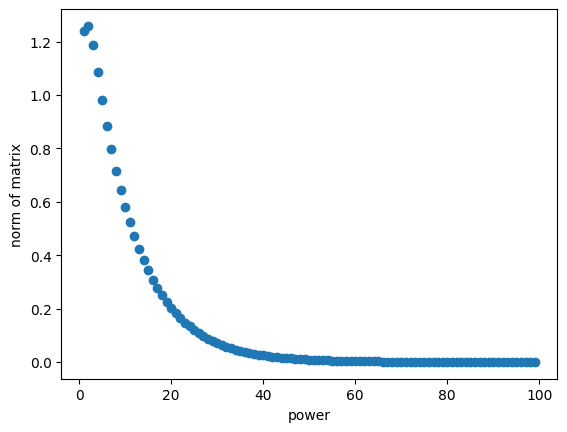

In [63]:
plt.plot(np.arange(1, 100),norm, 'o')
plt.xlabel('power')
plt.ylabel('norm of matrix')
plt.show()


In [68]:
A = np.random.normal(0, 1, 1250).reshape(50, 25)

In [69]:
B=A.T@A

In [70]:
lam, eig = np.linalg.eig(B)
 #Sort eigen values and eigen vectors
lam_sorted = lam[np.argsort(lam)[::-1]]
eig_sorted = eig[np.argsort(lam)[::-1]]
a = np.zeros([25,25])
for i in range(0, 15):
 a = a + lam_sorted[i] * eig_sorted[:,i].reshape(25,1) @ eig_sorted[:,i].reshape(1, 25)
 #Compare the Frobenious norm of original matrix B and reconstructed matrix a
 norm_B = np.linalg.norm(B)
 norm_a = np.linalg.norm(a)
 print ('Reconstruction %error:', abs(norm_B- norm_a)*100/norm_B)

Reconstruction %error: 56.55641180160364
Reconstruction %error: 43.24954498731151
Reconstruction %error: 33.922260505780464
Reconstruction %error: 26.556906372122526
Reconstruction %error: 21.378512362373947
Reconstruction %error: 16.799407595848415
Reconstruction %error: 13.623675370341186
Reconstruction %error: 10.882063429756721
Reconstruction %error: 8.85067461266277
Reconstruction %error: 6.9932219699354485
Reconstruction %error: 5.446132493899237
Reconstruction %error: 4.41778529187263
Reconstruction %error: 3.5447668237915524
Reconstruction %error: 2.7754930918710583
Reconstruction %error: 2.141106373059252


In [71]:
import numpy as np

# Step 1: Create random matrix
A = np.random.normal(0, 1, (50, 25))

# Step 2: Square symmetric matrix
B = A.T @ A

# Step 3: Eigen decomposition
lam, eig = np.linalg.eig(B)

# Step 4: Sort eigenvalues and eigenvectors
idx = np.argsort(lam)[::-1]           # indices for descending order
lam_sorted = lam[idx][:15]            # top 15 eigenvalues
eig_sorted = eig[:, idx][:, :15]      # corresponding eigenvectors

# Step 5: Reconstruct using top 15 components (vectorized)
a = eig_sorted @ np.diag(lam_sorted) @ eig_sorted.T

# Step 6: Compute reconstruction error
reconstruction_error = abs(np.linalg.norm(B) - np.linalg.norm(a)) * 100 / np.linalg.norm(B)
print("Reconstruction %error:", reconstruction_error)


Reconstruction %error: 1.5474753081691965
